In [2]:
Interesting_regions =   [4, 5, 32, 33, 44, 45, 48, 49]
Interesting_right =   [5, 33, 45, 49]
Interesting_left =   [4, 32, 44, 48]

Good_subjects =         [0, 2, 5, 9, 12, 14]
Ok_subjects =           [1, 3, 4, 6, 11, 13, 19]
Other_subjects = [i for i in range(20) if i not in Ok_subjects and i not in Good_subjects]

Subjects_dict = {"Good_subjects": Good_subjects, "Ok_subjects":Ok_subjects, "Other_subjects":Other_subjects}

data_folder="../Data/"

freq_personalized = {"subject_0":[9,14.5],
                     "subject_1":[8,12],
                     "subject_2":[8,13.5],
                     "subject_3":[4,9.5],
                     "subject_4":[18,23.5],
                     "subject_5":[4,9.5],
                     "subject_6":[4,9.5],
                     "subject_7":[4,9.5],
                     "subject_8":[4,12],
                     "subject_9":[9.5,15.5],
                     "subject_10":[9,14.5],
                     "subject_11":[4,10.5],
                     "subject_12":[8,13.5],
                     "subject_13":[4,10.],
                     "subject_14":[12,18],
                     "subject_15":[4,8],
                     "subject_16":[4,13],
                     "subject_17":[4,12],
                     "subject_18":[4,9.5],
                     "subject_19":[4,12.5],
}

from BCI_Library import read_subject, plot_brain, train_models, extract_features_more_bands, select_regions_Cohen_effect_size, compute_welch
from BCI_Library import saveresults_pickle, select_rows, compute_welch, extract_features_from_spectra_more_bands,cohens_d_per_columm, select_rows


In [ ]:
from sklearn.model_selection import StratifiedKFold 
import numpy as np
import pandas as pd
from datetime import date
import tqdm
n_folds=5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=224)
today = date.today()
sfreq = 250
ROI =13
quanteroi = 68
saveresults = True
filepath = "../Results/RegionSelection/Selected_regions"

DataType = "EEG"
    
subject_index = 0 

data_2_MI = read_subject(data_folder, DataType, "MI", subject_index, verbose=False)
data_2_Rest =read_subject(data_folder, DataType, "Baseline", subject_index, verbose=False)
WMI, WRe, FreqMI = compute_welch(data_2_MI, data_2_Rest, sfreq,
                                kargs_welch={"fmin":8, "fmax":30},
                                #starttime=750,
                                )

cohens_d_per_columm(WMI[:,ROI],WRe[:,ROI],return_all=True)

array([-0.20022119, -0.75798945, -1.19609067, -1.13552225, -1.29018219,
       -1.00193354, -0.81433431, -0.44881227, -0.26244042, -0.09317718,
       -0.04929547, -0.07206923, -0.15276291, -0.19800524, -0.20977128,
       -0.3572777 , -0.4373532 , -0.42541345, -0.29919351, -0.23791096,
       -0.1238987 , -0.15315306, -0.14373938, -0.04892952, -0.06171731,
       -0.08563473, -0.17950148])

In [14]:
My_cohen = cohens_d_per_columm(WMI[:,ROI],WRe[:,ROI],return_all=True)

In [16]:
import pingouin
for i in range(WMI.shape[2]):
    Pingouin_cohen = pingouin.compute_effsize(WMI[:,ROI,i],WRe[:,ROI,i], paired=True, eftype='cohen')
    print(Pingouin_cohen, "\t",Pingouin_cohen - My_cohen[i])

-0.2002211916809305 	 1.3600232051658168e-15
-0.7579894478241868 	 6.661338147750939e-16
-1.196090667615546 	 -6.661338147750939e-16
-1.135522245285393 	 -8.881784197001252e-16
-1.2901821884836038 	 -8.881784197001252e-16
-1.0019335355937642 	 1.1102230246251565e-15
-0.8143343096420107 	 0.0
-0.4488122698361581 	 1.4432899320127035e-15
-0.26244041633412873 	 0.0
-0.09317718117146621 	 2.498001805406602e-16
-0.04929546567392271 	 -7.355227538141662e-16
-0.07206923283131467 	 -7.91033905045424e-16
-0.15276290963133343 	 3.3306690738754696e-16
-0.19800524389451615 	 5.551115123125783e-17
-0.20977127843363616 	 -1.609823385706477e-15
-0.3572776981682391 	 -5.551115123125783e-17
-0.43735320037863135 	 1.3322676295501878e-15
-0.42541345191137403 	 -1.5543122344752192e-15
-0.29919351444400355 	 -3.885780586188048e-16
-0.23791095650993715 	 -1.942890293094024e-16
-0.12389869513170843 	 -5.551115123125783e-17
-0.15315306099533565 	 4.163336342344337e-16
-0.14373938270380107 	 0.0
-0.04892951801

In [7]:
WMI[:,ROI].shape

(78, 27)

# TEST

In [7]:
import pandas as pd

Rows = pd.DataFrame({
    "ROIs": [],
    "NROIs":[],
    "DataType": [],
    "freqs_band": [],  
    "subject": [],
    "Classifier": [],
    "Performance": [],
    "Features": [],
    "Comments": [],
    "Date": [],
    "Personalized_Freq_Range":[]
})

Rows.to_pickle("../Results/BCI_Performances_region_selection_on_repeated_10folds_8_30_Hz.pkl")

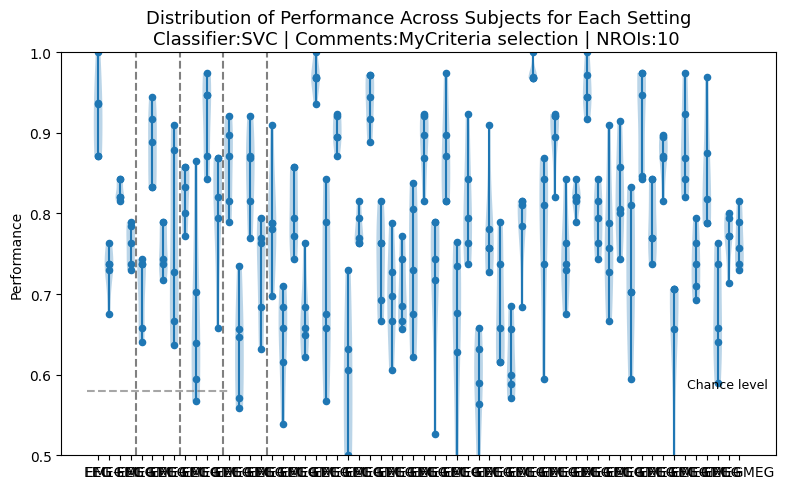

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

num_settings_showed_per_subject = 3
MyDATA = pd.read_pickle("../Results/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")

dict_fixed_selection = {"Classifier":"SVC", "Comments":"MyCriteria selection", "NROIs":10}

Datatypes=["EEG"]+ ["MEG"]+ ["EEG concat MEG"]
dict_per_setting = {"DataType":Datatypes}
xlabel = ""
hlines_positions = []
x_ticklabels_per_subject = [_.replace(" concat ", "+") for _ in Datatypes]
x_ticklabels = x_ticklabels_per_subject * 20


PerData = MyDATA

chaanche_lvl = 0.58 # https://pubmed.ncbi.nlm.nih.gov/25596422/
hlines_positions = hlines_positions +  [chaanche_lvl]
vlines_positions = [3.5,7.5,11.5,15.5]

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

nps = num_settings_showed_per_subject
x_positions = np.arange(nps*20)

size=20

perfs_per_subject = []



for setting in range(nps):
    for subject in range(20):
        # Extract performances
        tmp_dict = {"subject":subject}
        for key in dict_per_setting:
            tmp_dict[key] = dict_per_setting[key][setting]
        rows = select_rows(PerData, dict_fixed_selection | tmp_dict)
        perfs_per_subject.append(np.array(list(rows["Performance"].values)))

perfs = np.array(perfs_per_subject).squeeze()   # (60, 5)
x_plot = np.repeat(x_positions, perfs.shape[1]) # (300,)
y_plot = perfs.flatten()                         # (300,)


ax.scatter(x_plot, y_plot,s=size)#facecolors='none',edgecolors=color


    
perfs_per_subject = np.array(perfs_per_subject)   # shape (20 subjects, 9 settings)

#Violin plot
ax_violin = ax
violins = ax_violin.violinplot(
    perfs.T,
    positions=x_positions,
    showmeans=False,
    showmedians=True,
    widths=0.8,
)

for part in violins['bodies']+[violins['cbars']]:
    part.set_zorder(-20)
xlims = ax.get_xlim()
ax_violin.set_ylabel("Performance")
ax_violin.set_xlabel(xlabel)
ax.hlines(hlines_positions, -1, 12, colors='grey', linestyles='dashed', label="Chance Level",zorder=-1, alpha=0.7)
ax.set_xticks(x_positions)
ax.set_xticklabels(x_ticklabels)
ax.vlines(vlines_positions, 0.5, 1, colors='gray', linestyles='dashed')
ax.set_ylim(0.5, 1)
# for __ in range(len(textes)):
#     ax.text(textes_x_positions[__], 0.1, textes[__], transform=ax.transAxes, fontsize=12, verticalalignment='top',horizontalalignment='center')

ax.text(1., 0.192, f"Chance level  ", transform=ax.transAxes, fontsize=9, verticalalignment='top',horizontalalignment='right')
title = f"Distribution of Performance Across Subjects for Each Setting\n"
for key,value in dict_fixed_selection.items():
    title+= f"{key}:{value} | "
title=title[:-2]
ax.set_title(title, fontsize=13)
ax.set_xlim(xlims)
plt.tight_layout()
# if savepath:
#     plt.savefig(savepath,dpi=300)
plt.show()


EEG
0 

##########################################################
MEG
0 

##########################################################
EEG concat MEG
0 

##########################################################
EEG
1 

##########################################################
MEG
1 

##########################################################
EEG concat MEG
1 

##########################################################
EEG
2 

##########################################################
MEG
2 

##########################################################
EEG concat MEG
2 

##########################################################
EEG
3 

##########################################################
MEG
3 

##########################################################
EEG concat MEG
3 

##########################################################
EEG
4 

##########################################################
MEG
4 

##########################################################
EEG concat MEG
4 


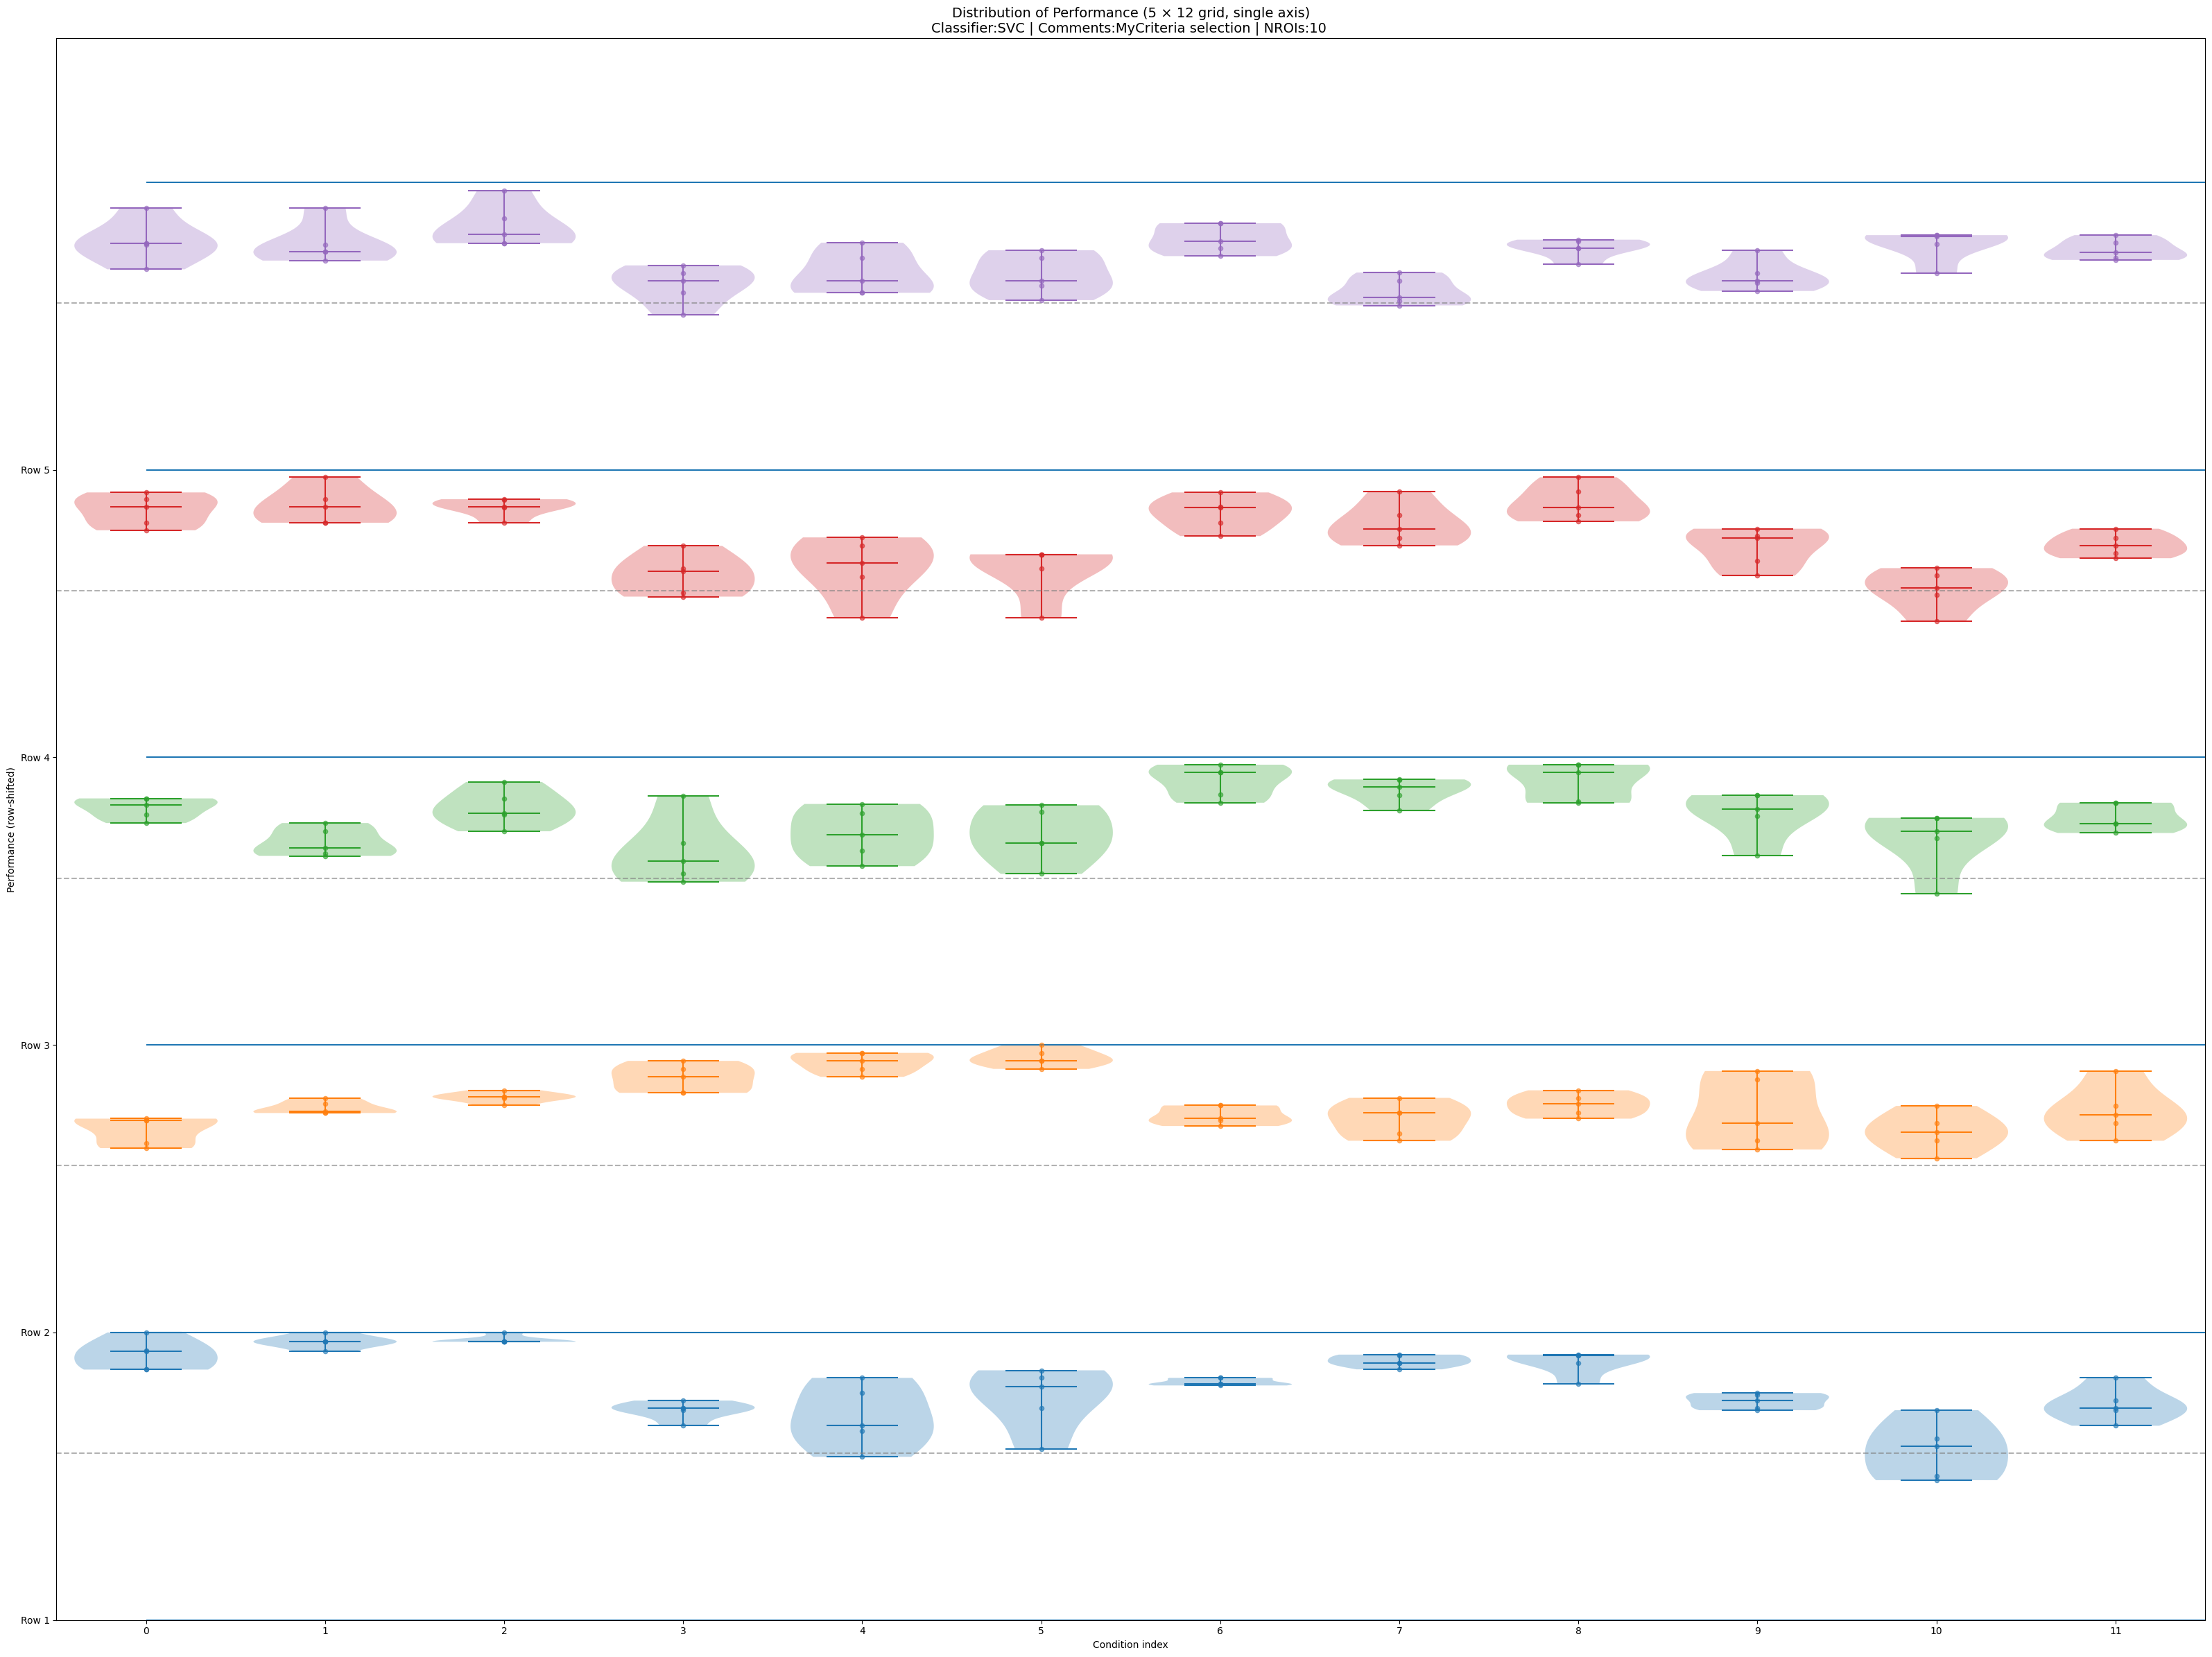

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# PARAMETERS
# ==========================
num_subjects = 20
num_settings_showed_per_subject = 3
n_rows = 5
n_cols = 12
row_height = 1.0

size = 20

# ==========================
# LOAD DATA
# ==========================
MyDATA = pd.read_pickle(
    "../Results/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl"
)

dict_fixed_selection = {
    "Classifier": "SVC",
    "Comments": "MyCriteria selection",
    "NROIs": 10,
}

Datatypes = ["EEG", "MEG", "EEG concat MEG"]
dict_per_setting = {"DataType": Datatypes}

PerData = MyDATA

# ==========================
# COLLECT PERFORMANCES
# ==========================
perfs_per_subject = []

for subject in range(num_subjects):
    for setting in range(num_settings_showed_per_subject):

        tmp_dict = {"subject": subject}
        for key in dict_per_setting:
            tmp_dict[key] = dict_per_setting[key][setting]
            print(tmp_dict[key])
        print(subject,"\n\n##########################################################")

        rows = select_rows(PerData, dict_fixed_selection | tmp_dict)
        perfs_per_subject.append(
            np.array(list(rows["Performance"].values))
        )

# Shape: (60, 5)
perfs = np.array(perfs_per_subject).squeeze()

assert perfs.shape[0] == n_rows * n_cols

# ==========================
# RESHAPE INTO GRID
# ==========================
# Shape: (5 rows, 12 violins per row, 5 samples)
perfs_grid = perfs.reshape(n_rows, n_cols, perfs.shape[1])

# ==========================
# PLOT
# ==========================
fig, ax = plt.subplots(figsize=(32, 24))

for row in range(n_rows):
    y_offset = row * row_height

    data_row = perfs_grid[row] + y_offset   # vertical shift
    x_row = np.arange(n_cols)

    # ---- Violin plot ----
    violins = ax.violinplot(
        data_row.T,
        positions=x_row,
        widths=0.8,
        showmeans=False,
        showmedians=True,
    )

    for part in violins['bodies'] + [violins['cbars']]:
        part.set_zorder(-20)

    # ---- Scatter overlay ----
    x_scatter = np.repeat(x_row, data_row.shape[1])
    y_scatter = data_row.flatten()

    ax.scatter(
        x_scatter,
        y_scatter,
        s=size,
        alpha=0.6,
        zorder=10,
    )

# ==========================
# AXIS FORMATTING
# ==========================
ax.set_xlim(-0.5, n_cols - 0.5)
ax.set_ylim(0.5, n_rows * row_height + 0.5)

ax.set_xticks(np.arange(n_cols))
ax.set_xlabel("Condition index")

ax.set_yticks(np.arange(n_rows) * row_height)
ax.set_yticklabels([f"Row {i+1}" for i in range(n_rows)])
ax.set_ylabel("Performance (row-shifted)")

# Chance level (applied to each row)
chance_lvl = 0.58
for row in range(n_rows):
    ax.hlines(
        chance_lvl + row * row_height,
        -0.5,
        n_cols - 0.5,
        colors="gray",
        linestyles="dashed",
        alpha=0.6,
        zorder=-5,
    )
ax.hlines([0,1,2,3,4,5],0,15)
# ==========================
# TITLE
# ==========================
title = "Distribution of Performance (5 × 12 grid, single axis)\n"
for k, v in dict_fixed_selection.items():
    title += f"{k}:{v} | "
ax.set_title(title[:-2], fontsize=14)

plt.tight_layout()
plt.show()


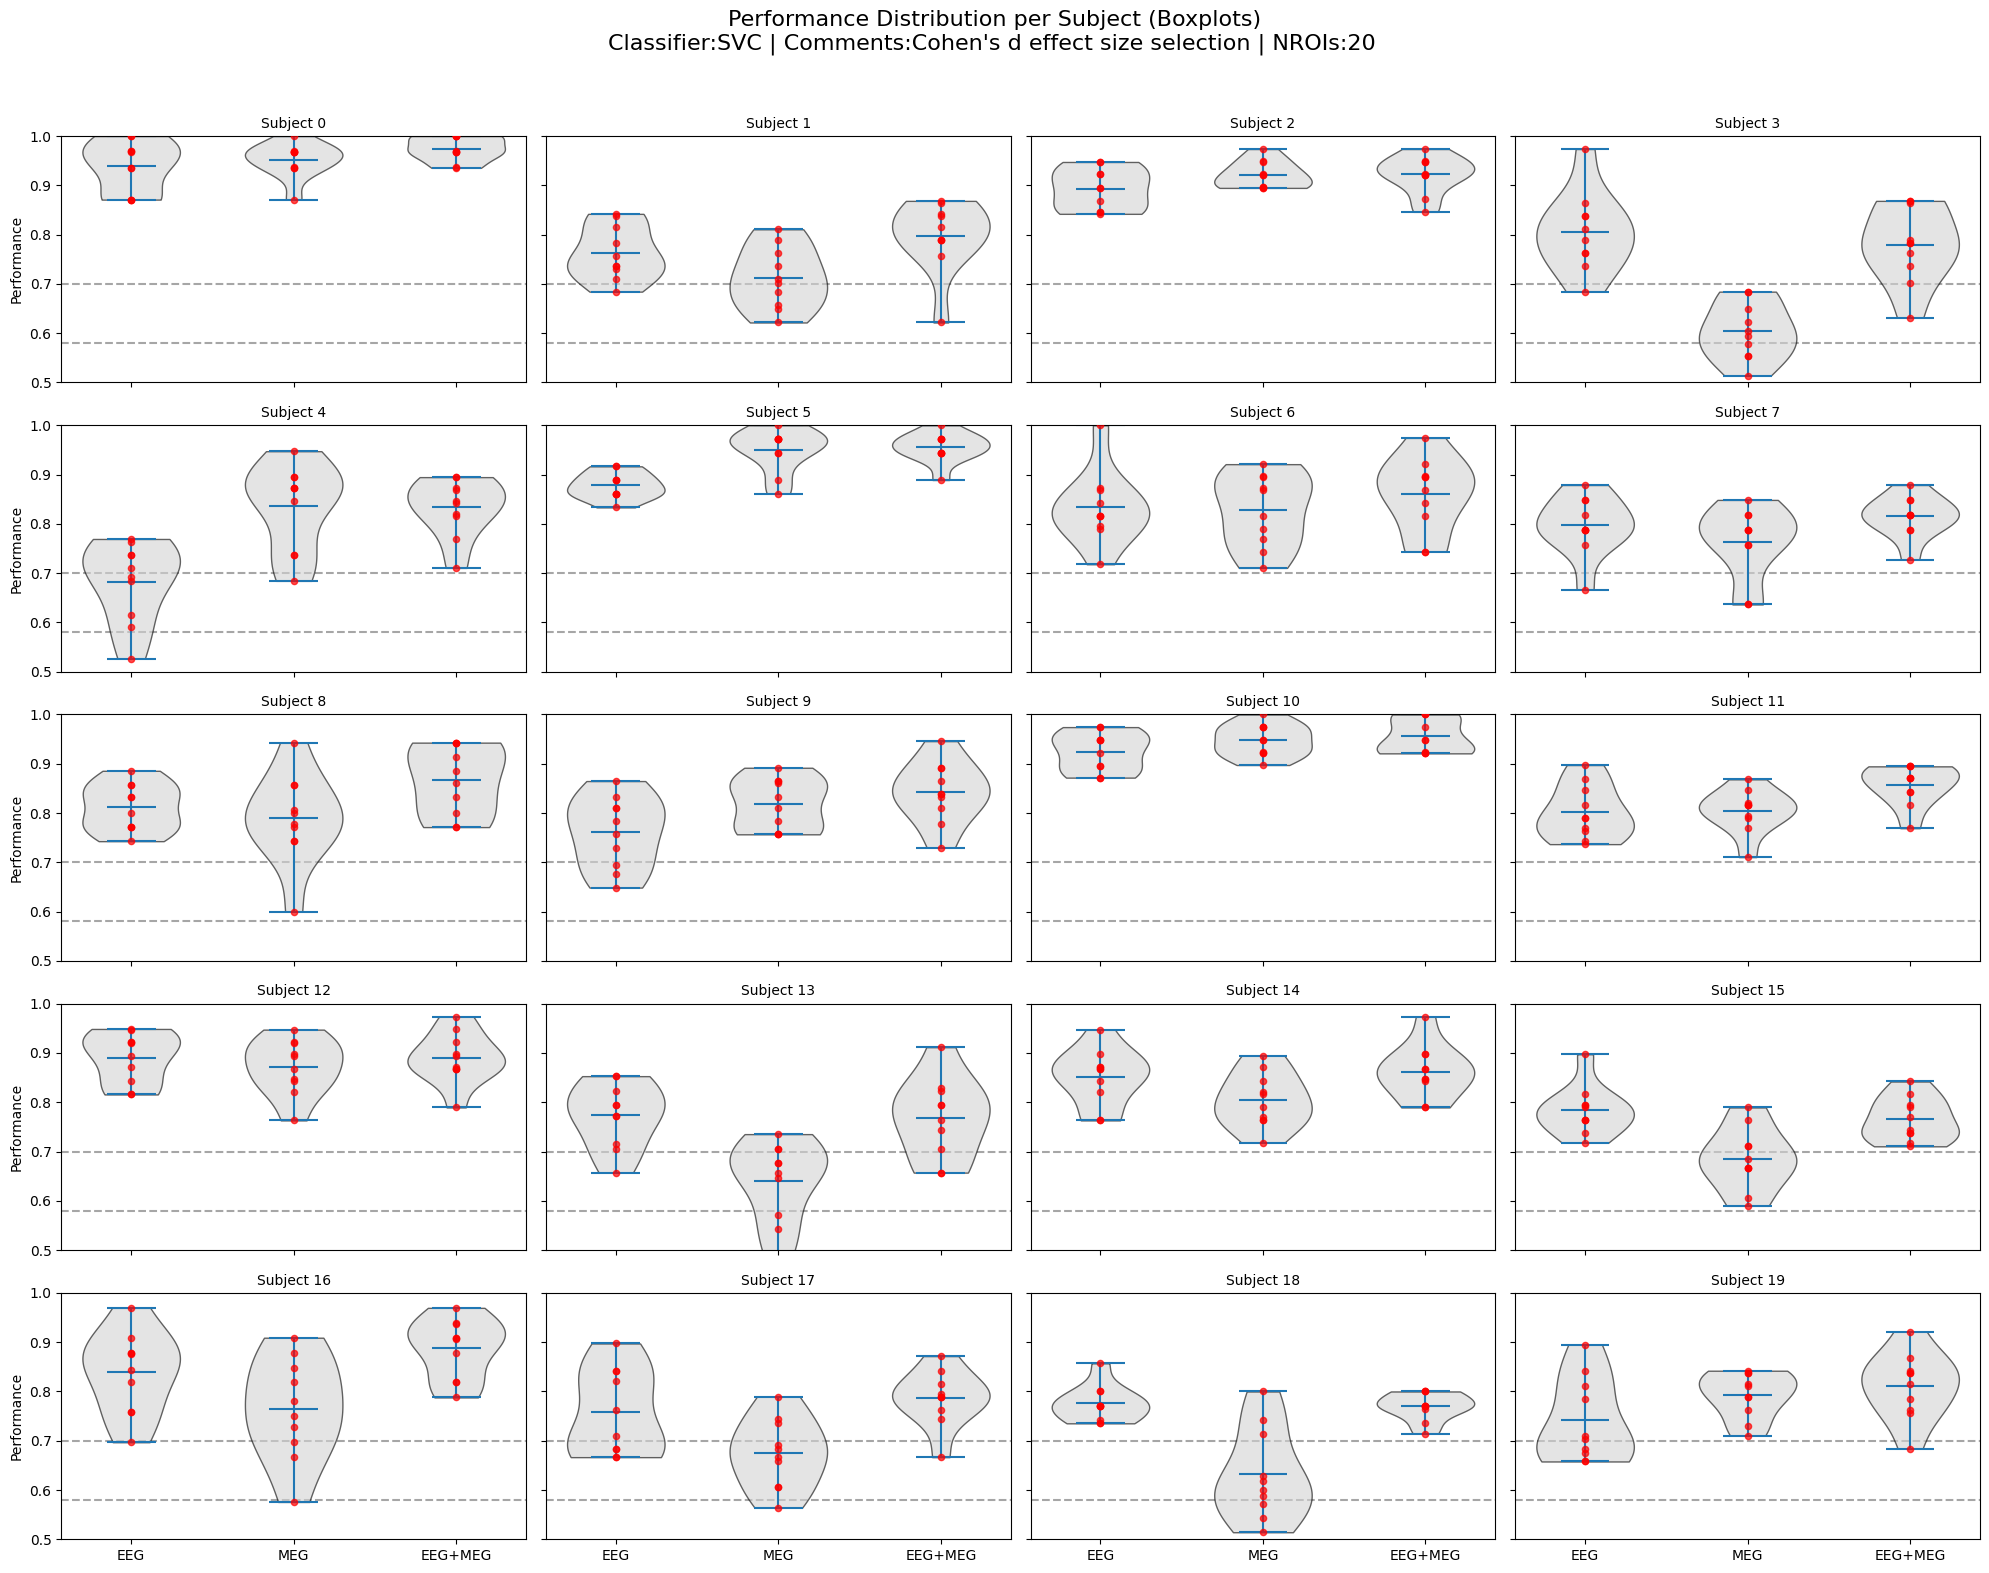

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# PARAMETERS
# ==========================
num_subjects = 20
num_settings_showed_per_subject = 3
n_rows = 5
n_cols = 4

size = 20
hlines_positions = [0.7]

chance_lvl = 0.58
hlines_positions = hlines_positions + [chance_lvl]
# ==========================
# LOAD DATA
# ==========================
MyDATA = pd.read_pickle(
    "../Results/BCI_Performances_region_selection_on_repeated_10folds_8_30_Hz.pkl"
)

dict_fixed_selection = {
    "Classifier": "SVC",
    "Comments": "Cohen's d effect size selection",
    "NROIs": 20,
}

Datatypes = ["EEG", "MEG", "EEG concat MEG"]
dict_per_setting = {"DataType": Datatypes}


########################################################################################################################
PerData = MyDATA

x_positions = np.arange(num_settings_showed_per_subject)
x_labels = ["EEG", "MEG", "EEG+MEG"]

# ==========================
# CREATE FIGURE
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(20, 16),
    sharex=True,
    sharey=True
); axes = axes.flatten()

# ==========================
# LOOP OVER SUBJECTS
for subject in range(num_subjects):
    ax = axes[subject]

    perfs_subject = []

    for setting in range(num_settings_showed_per_subject):
        tmp_dict = {"subject": subject}
        for key in dict_per_setting:
            tmp_dict[key] = dict_per_setting[key][setting]

        rows = select_rows(PerData, dict_fixed_selection | tmp_dict)
        perfs_subject.append(
            np.array(list(rows["Performance"].values))
        )

    # Shape: (3, 5)
    perfs_subject = np.array(perfs_subject)

    # ----------------------
    # BOXPLOT
    # ----------------------
    perfs_subjectbp = [np.asarray(p).ravel() for p in perfs_subject]

    vp = ax.violinplot(
        perfs_subjectbp,
        positions=x_positions,
        widths=0.6,
        showmeans=True
    )

    for body in vp['bodies']: 
        body.set_facecolor("lightgray")
        body.set_edgecolor("black") 
        body.set_alpha(0.6)

    x_scatter = np.repeat(x_positions, perfs_subject.shape[1])
    y_scatter = perfs_subject.flatten()
    x_scatter= np.repeat(x_scatter, perfs_subject.shape[-1])

    ax.scatter(
        x_scatter,
        y_scatter,
        s=size,
        alpha=0.7,
        zorder=10,
        color="red"
        )
    xmin, xmax = ax.get_xlim()
    # CHANCE LEVEL
    ax.hlines(
        hlines_positions,
        xmin,
        xmax,
        colors="gray",
        linestyles="dashed",
        alpha=0.7,
        zorder=0,
    )
    ax.set_xlim(xmin, xmax)
    ax.set_title(f"Subject {subject}", fontsize=10)

# ==========================
# AXIS FORMATTING
for ax in axes[-n_cols:]:
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels)

for ax in axes[::n_cols]:
    ax.set_ylabel("Performance")

axes[0].set_ylim(0.5, 1.0)

# Remove unused axes if any
for ax in axes[num_subjects:]:
    ax.axis("off")

# ==========================
# GLOBAL TITLE
# ==========================
title = "Performance Distribution per Subject (Boxplots)\n"
for k, v in dict_fixed_selection.items():
    title += f"{k}:{v} | "

fig.suptitle(title[:-2], fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
